# Deep Learning Systems
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Exploration and Preprocessing](#prep)
- [Base Model Implementation and Training](#base)
- [Experimental Model Implementation and Training](#exper)
- [Model Evaluation](#eval)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we ...

We start by loading, cleaning and rescaling the data. We then ..., and conclude by a short summary of our findings.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip3 install torch torchvision

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
reset_data_imports = False
if(reset_data_imports):
    !pip install yfinance
    import yfinance as yf
    df_vix = yf.download(tickers=["^SPX"], start='2006-04-15', end='2026-04-15')
    df_vix.columns = ['Close','High','Low','Open','Volume']
    df_vix.to_csv('./spx.csv')
    df_vix = yf.download(tickers=["^VIX"], start='2006-04-15', end='2026-04-15')
    df_vix.columns = ['Close','High','Low','Open','Volume']
    df_vix.to_csv('./vix.csv')

In [5]:
df_spx = pd.read_csv("spx.csv")
df_vix = pd.read_csv("vix.csv")

In [6]:
df_spx.head()

,Date,Close,High,Low,Open,Volume
0,2006-04-17,1285.329956,1292.449951,1280.739990,1289.119995,1794650000
1,2006-04-18,1307.280029,1309.020020,1285.329956,1285.329956,2595440000
2,2006-04-19,1309.930054,1310.390015,1302.790039,1307.650024,2447310000
3,2006-04-20,1311.459961,1318.160034,1306.380005,1309.930054,2512920000
4,2006-04-21,1311.280029,1317.670044,1306.589966,1311.459961,2392630000


In [7]:
df_vix.head()

,Date,Close,High,Low,Open,Volume
0,2006-04-17,12.58,13.02,12.27,12.80,0
1,2006-04-18,11.40,12.55,11.31,12.55,0
2,2006-04-19,11.32,11.80,11.23,11.52,0
3,2006-04-20,11.64,11.67,11.02,11.30,0
4,2006-04-21,11.59,11.98,11.19,11.24,0


<a id='prep'></a>
### Data Exploration and Preprocessing

In this section, we explore the data and perform some cleaning and rescaling steps.

In [8]:
df_spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5030 non-null   object 
 1   Close   5030 non-null   float64
 2   High    5030 non-null   float64
 3   Low     5030 non-null   float64
 4   Open    5030 non-null   float64
 5   Volume  5030 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 235.9+ KB


In [9]:
df_vix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5030 non-null   object 
 1   Close   5030 non-null   float64
 2   High    5030 non-null   float64
 3   Low     5030 non-null   float64
 4   Open    5030 non-null   float64
 5   Volume  5030 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 235.9+ KB


In [10]:
df_spx.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
df_spx.Date = pd.to_datetime(df_spx.Date)
df_vix.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
df_vix.Date = pd.to_datetime(df_vix.Date)

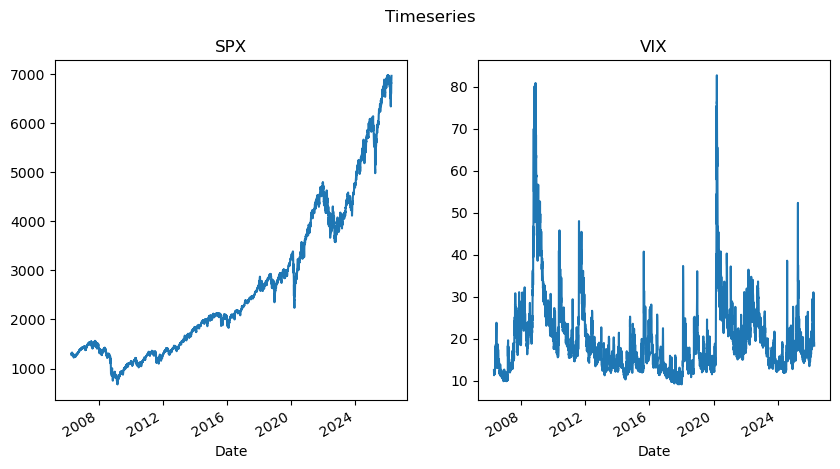

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Timeseries')
df_spx.plot(x='Date', y='Close', ax=ax[0]);
df_vix.plot(x='Date', y='Close', ax=ax[1]);
ax[0].set(title='SPX')
ax[1].set(title='VIX')
ax[0].get_legend().remove()
ax[1].get_legend().remove()
plt.show()

In [12]:
df_spx.Close.describe()

count    5030.000000
mean     2680.589053
std      1571.951612
min       676.530029
25%      1387.900055
50%      2102.789917
75%      3823.702393
max      6978.600098
Name: Close, dtype: float64

In [13]:
df_vix.Close.describe()

count    5030.000000
mean       19.583278
std         8.707569
min         9.140000
25%        13.860000
50%        17.240000
75%        22.559999
max        82.690002
Name: Close, dtype: float64

In [14]:
def split_scale_df(df):
    '''
    TODO
    '''
    n_df = len(df.index)
    df_train = df.loc[:0.8*n_df].copy()
    df_train['LogClose'] = df_train.apply(lambda row: np.log(row['Close']), axis=1)
    mean_logclose = df_train['LogClose'].mean()
    df_train['LogClose'] = df_train.apply(lambda row: row['LogClose']-mean_logclose, axis=1)
    df_test = df.loc[0.8*n_df:].copy()
    df_test['LogClose'] = df_test.apply(lambda row: np.log(row['Close']), axis=1)
    df_test['LogClose'] = df_test.apply(lambda row: row['LogClose']-mean_logclose, axis=1)
    return (df_train, df_test, mean_logclose)

In [15]:
(df_train_spx, df_test_spx, mean_spx) = split_scale_df(df_spx)
(df_train_vix, df_test_vix, mean_vix) = split_scale_df(df_vix)

In [16]:
autocorr_spx = pd.DataFrame([[l,df_spx.Close.autocorr(lag=l)] for l in range(200)])
autocorr_spx.columns = ['lag','corr']
autocorr_vix = pd.DataFrame([[l,df_vix.Close.autocorr(lag=l)] for l in range(200)])
autocorr_vix.columns = ['lag','corr']

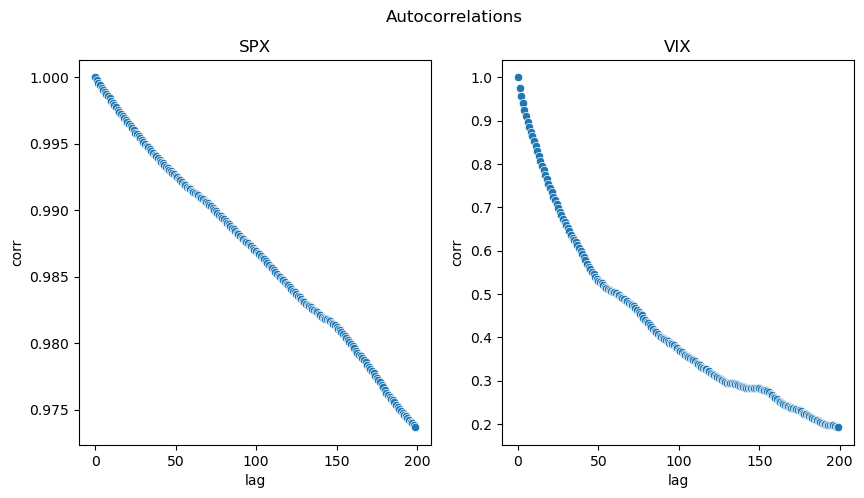

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Autocorrelations')
sns.scatterplot(autocorr_spx,x='lag',y='corr', ax=ax[0]);
sns.scatterplot(autocorr_vix,x='lag',y='corr', ax=ax[1]);
ax[0].set(title='SPX')
ax[1].set(title='VIX')
plt.show()

In [18]:
window_size = 20

In [19]:
def split_windows(values, window_size):
    '''
    TODO
    '''
    windows = []
    labels = []
    for i in range(len(values) - window_size-1):
        windows.append(values[i : i + window_size])
        labels.append(values[i + window_size])
    windows = np.array(windows, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)
    return (windows, labels)

In [20]:
(windows_train_spx, labels_train_spx) = split_windows(df_train_spx[['LogClose']].to_numpy(), window_size)
x_train_spx = torch.tensor(windows_train_spx)
y_train_spx = torch.tensor(labels_train_spx)

(windows_test_spx, labels_test_spx) = split_windows(df_test_spx[['LogClose']].to_numpy(), window_size)
x_test_spx = torch.tensor(windows_test_spx)
y_test_spx = torch.tensor(labels_test_spx)

In [21]:
(windows_train_vix, labels_train_vix) = split_windows(df_train_vix[['LogClose']].to_numpy(), window_size)
x_train_vix = torch.tensor(windows_train_vix)
y_train_vix = torch.tensor(labels_train_vix)

(windows_test_vix, labels_test_vix) = split_windows(df_test_vix[['LogClose']].to_numpy(), window_size)
x_test_vix = torch.tensor(windows_test_vix)
y_test_vix = torch.tensor(labels_test_vix)

In [22]:
print(x_train_vix.shape)
print(y_train_vix.shape)

torch.Size([4004, 20, 1])
torch.Size([4004, 1])


In [23]:
class MyDataset(Dataset):
    '''
    TODO
    '''
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [24]:
dataset_train_spx = MyDataset(x_train_spx, y_train_spx)
loader_train_spx = DataLoader(dataset_train_spx, batch_size=32, shuffle=True)
dataset_test_spx = MyDataset(x_test_spx, y_test_spx)
loader_test_spx = DataLoader(dataset_test_spx, batch_size=32, shuffle=True)

In [25]:
dataset_train_vix = MyDataset(x_train_vix, y_train_vix)
loader_train_vix = DataLoader(dataset_train_vix, batch_size=32, shuffle=True)
dataset_test_vix = MyDataset(x_test_vix, y_test_vix)
loader_test_vix = DataLoader(dataset_test_vix, batch_size=32, shuffle=True)

<a id='base'></a>
### Base Model Implementation and Training

We now ...

In [26]:
criterion = nn.MSELoss()

In [27]:
def train_model(model, optimizer, loader_train, loader_test, epochs):
    '''
    TODO
    '''
    train_losses, test_losses, accuracies = [], [], []
    for e in range(epochs):
        running_loss = 0
        for images, labels in loader_train:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            output = model.forward(images)

            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        else:
            test_loss = 0
            accuracy = 0
    
            with torch.no_grad():
                model.eval()
                for images, labels in loader_test:
                    images = images.to(device)
                    labels = labels.to(device)
                    
                    log_ps = model(images)
                    test_loss += criterion(log_ps, labels).item()
                    
                    ps = torch.exp(log_ps)
                    top_p, top_class = ps.topk(1, dim=1)
            model.train()
            
            train_losses.append(running_loss/len(loader_train))
            test_losses.append(test_loss/len(loader_test))
    
            print("Epoch: {}/{}.. ".format(e+1, epochs),
                  "Training Loss: {:.3f}.. ".format(running_loss/len(loader_train)),
                  "Test Loss: {:.3f}.. ".format(test_loss/len(loader_test))
            )
    return (train_losses, test_losses, accuracies)

In [28]:
class ExtractTensor(nn.Module):
    def forward(self,x):
        # Output shape (batch, features, hidden)
        tensor, _ = x
        # Reshape shape (batch, hidden)
        return tensor[:, -1, :]

In [29]:
model_base_spx = nn.Sequential(
    nn.LSTM(x_train_spx.shape[2], 256, num_layers=2), 
    ExtractTensor(),
    nn.Linear(256, x_train_spx.shape[2])
).to(device)
optimizer_base_spx = optim.Adam(model_base_spx.parameters(), lr=0.0005)

In [30]:
res_base_spx = train_model(model_base_spx, optimizer_base_spx, loader_train_spx, loader_test_spx, 10)

Epoch: 1/10..  Training Loss: 0.081..  Test Loss: 0.005.. 
Epoch: 2/10..  Training Loss: 0.001..  Test Loss: 0.003.. 
Epoch: 3/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 4/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 5/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 6/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 7/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 8/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 9/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 10/10..  Training Loss: 0.000..  Test Loss: 0.000.. 


In [31]:
model_base_vix = nn.Sequential(
    nn.LSTM(x_train_vix.shape[2], 256, num_layers=2), 
    ExtractTensor(),
    nn.Linear(256, x_train_vix.shape[2])
).to(device)
optimizer_base_vix = optim.Adam(model_base_vix.parameters(), lr=0.0005)

In [32]:
res_base_vix = train_model(model_base_vix, optimizer_base_vix, loader_train_vix, loader_test_vix, 10)

Epoch: 1/10..  Training Loss: 0.071..  Test Loss: 0.008.. 
Epoch: 2/10..  Training Loss: 0.007..  Test Loss: 0.006.. 
Epoch: 3/10..  Training Loss: 0.007..  Test Loss: 0.006.. 
Epoch: 4/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 5/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 6/10..  Training Loss: 0.006..  Test Loss: 0.005.. 
Epoch: 7/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 8/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 9/10..  Training Loss: 0.006..  Test Loss: 0.005.. 
Epoch: 10/10..  Training Loss: 0.006..  Test Loss: 0.006.. 


In [33]:
act_spx = np.exp(y_test_spx+mean_spx).detach().cpu().numpy()
pred_base_spx = model_base_spx.forward(x_test_spx).detach().cpu().numpy()
pred_base_spx= np.exp(pred_base_spx+mean_spx)
diff_base_spx = pred_base_spx-act_spx

C:\Users\Andreas\AppData\Local\Temp\ipykernel_15324\3766228792.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  act_spx = np.exp(y_test_spx+mean_spx).detach().cpu().numpy()


In [44]:
act_vix = np.exp(y_test_vix+mean_vix).detach().cpu().numpy()
pred_base_vix = model_base_vix.forward(x_test_vix).detach().cpu().numpy()
pred_base_vix= np.exp(pred_base_vix+mean_vix)
diff_base_vix = pred_base_vix-act_vix

C:\Users\Andreas\AppData\Local\Temp\ipykernel_15324\773525689.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  act_vix = np.exp(y_test_vix+mean_vix).detach().cpu().numpy()


<a id='exper'></a>
### Experimental Model Implementation and Training

We now ...

In [45]:
model_exp_spx = nn.Sequential(
    nn.Flatten(start_dim=1), 
    nn.Linear(x_train_spx.shape[1]*x_train_spx.shape[2], 128), 
    nn.ReLU(), 
    nn.Linear(128,64), 
    nn.ReLU(), 
    nn.Linear(64, x_train_spx.shape[2])
).to(device)
optimizer_exp_spx = optim.Adam(model_exp_spx.parameters(), lr=0.0005)

In [46]:
res_exp_spx = train_model(model_exp_spx, optimizer_exp_spx, loader_train_spx, loader_test_spx, 10)

Epoch: 1/10..  Training Loss: 0.019..  Test Loss: 0.001.. 
Epoch: 2/10..  Training Loss: 0.001..  Test Loss: 0.002.. 
Epoch: 3/10..  Training Loss: 0.001..  Test Loss: 0.001.. 
Epoch: 4/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 5/10..  Training Loss: 0.000..  Test Loss: 0.002.. 
Epoch: 6/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 7/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 8/10..  Training Loss: 0.000..  Test Loss: 0.000.. 
Epoch: 9/10..  Training Loss: 0.000..  Test Loss: 0.001.. 
Epoch: 10/10..  Training Loss: 0.000..  Test Loss: 0.001.. 


In [47]:
model_exp_vix = nn.Sequential(
    nn.Flatten(start_dim=1), 
    nn.Linear(x_train_vix.shape[1]*x_train_vix.shape[2], 128), 
    nn.ReLU(), 
    nn.Linear(128,64), 
    nn.ReLU(), 
    nn.Linear(64, x_train_vix.shape[2])
).to(device)
optimizer_exp_vix = optim.Adam(model_exp_vix.parameters(), lr=0.0005)

In [48]:
res_exp_vix = train_model(model_exp_vix, optimizer_exp_vix, loader_train_vix, loader_test_vix, 10)

Epoch: 1/10..  Training Loss: 0.025..  Test Loss: 0.009.. 
Epoch: 2/10..  Training Loss: 0.008..  Test Loss: 0.007.. 
Epoch: 3/10..  Training Loss: 0.007..  Test Loss: 0.006.. 
Epoch: 4/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 5/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 6/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 7/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 8/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 9/10..  Training Loss: 0.006..  Test Loss: 0.006.. 
Epoch: 10/10..  Training Loss: 0.006..  Test Loss: 0.006.. 


In [49]:
pred_exp_spx = model_exp_spx.forward(x_test_spx).detach().cpu().numpy()
pred_exp_spx = np.exp(pred_exp_spx+mean_spx)
diff_exp_spx = pred_exp_spx-act_spx

In [50]:
pred_exp_vix = model_exp_vix.forward(x_test_vix).detach().cpu().numpy()
pred_exp_vix = np.exp(pred_exp_vix+mean_vix)
diff_exp_vix = pred_exp_vix-act_vix

<a id='eval'></a>
### Model Evaluation

In this section, we ...

In [51]:
print(f'Mean relative error base: {np.mean(np.abs(pred_base_spx/act_spx-1))}')
print(f'Mean relative error exp: {np.mean(np.abs(pred_exp_spx/act_spx-1))}')

Mean relative error base: 0.008654947812429674
Mean relative error exp: 0.02537834616989654


In [52]:
print(f'Mean relative error base: {np.mean(np.abs(pred_base_vix/act_vix-1))}')
print(f'Mean relative error exp: {np.mean(np.abs(pred_exp_vix/act_vix-1))}')

Mean relative error base: 0.051787234771985165
Mean relative error exp: 0.05230754605669249


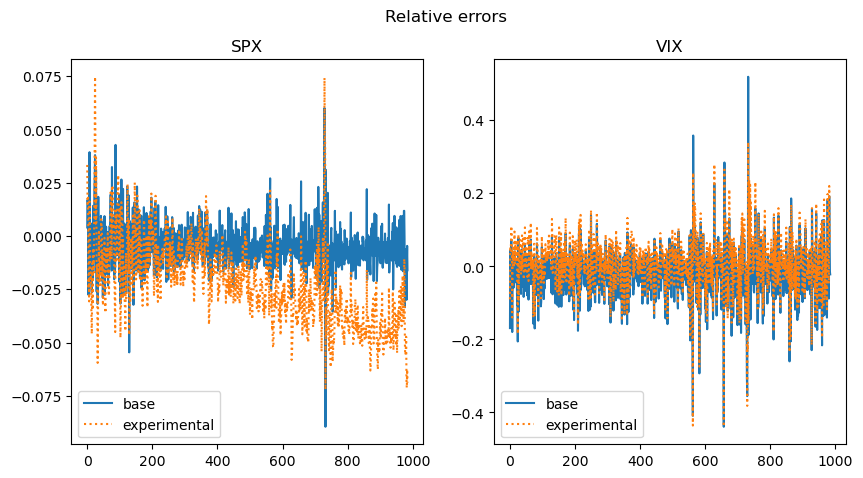

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Relative errors')
ax[0].plot(diff_base_spx/act_spx, label="base")
ax[0].plot(diff_exp_spx/act_spx,linestyle='dotted', label="experimental")
ax[1].plot(diff_base_vix/act_vix, label="base")
ax[1].plot(diff_exp_vix/act_vix,linestyle='dotted', label="experimental")
ax[0].set(title='SPX')
ax[1].set(title='VIX')
ax[0].legend(loc="lower left")
ax[1].legend(loc="lower left")
plt.show()

<a id='summary'></a>
### Summary

We have ...

In [ ]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt